In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))


# فصل 7 — ماشین‌های بردار پشتیبان (SVM)
## درس 10: مقیاس‌پذیر کردن SVMها (کرنل‌های تقریبی، SVM خطی، پیچیدگی)

این درس درباره یک سؤال کاملاً عملی است:

> **وقتی دیتاست آن‌قدر بزرگ می‌شود که SVM کرنلی کامل غیرعملی است، چگونه «ایده SVM» (طبقه‌بندی با حاشیه بزرگ) را حفظ می‌کنیم؟**

سه دیدگاه را به هم وصل می‌کنیم:

1. **دیدگاه بهینه‌سازی:** SVMهای کرنلی، برنامه‌ریزی‌های درجه دوم با یک ماتریس کرنل $n\times n$ هستند.
2. **دیدگاه سیستم‌ها:** بودجه حافظه و CPU شما را مجبور به تقریب می‌کند؛ «دقیق» اغلب ممکن نیست.
3. **دیدگاه مدل‌سازی:** SVMهای خطی وقتی فضای ویژگی بُعدبالا باشد (اغلب تنک)، می‌توانند بسیار قوی باشند.

ما با **سه دیتاست که (به‌صورت تصادفی) از مخزن شما انتخاب شده‌اند** کار می‌کنیم:

- `../../../Datasets/Classification/glass.csv` (چندکلاسه، عددی)
- `../../../Datasets/Classification/stars.csv` (ترکیبی عددی + دسته‌ای)
- `../../../Datasets/Classification/diabetes.csv` (دودویی، عددی)

### اهداف یادگیری

در پایان باید بتوانید:

1. **پیچیدگی زمانی و حافظه‌ای** SVMهای کرنلی را توضیح دهید (ساخت Gram matrix + حل QP).
2. تشخیص دهید چه زمانی **SVM خطی** بهترین baseline است (خصوصاً برای ویژگی‌های تنک با بُعد بالا).
3. آموزش مقیاس‌پذیر SVM خطی را با `LinearSVC` و `SGDClassifier(loss="hinge")` پیاده‌سازی کنید.
4. SVM کرنلی را با **ویژگی‌های کرنلِ تقریبی** جایگزین کنید (با `RBFSampler` و `Nystroem`).
5. یک حلقه ارزیابی مناسب تولید بسازید: **Pipeline**، **Cross-Validation** و **Calibration** (وقتی احتمال لازم است).
6. معامله دقت/زمان را با یک **بودجه پیچیدگی** بخوانید و انتخاب خود را توجیه کنید.

---

### نقشه ذهنی

```mermaid
flowchart TD
    A["Data size (n) and dimension (d)"] --> B["Need nonlinear boundary?"]
    B -->|No| C["Linear SVM (primal)"]
    B -->|Yes| D["Can you afford kernel SVM? (O(n^2) memory)"]
    D -->|Yes| E["Kernel SVM (SVC)"]
    D -->|No| F["Approximate kernel features"]
    F --> G["Random Fourier Features (RBFSampler)"]
    F --> H["Nyström approximation (Nystroem)"]
    C --> I["Tune C / alpha"]
    G --> J["Tune n_components + gamma + C"]
    H --> K["Tune n_components + gamma + C"]
    I --> L["(Optional) Calibrate probabilities"]
    J --> L
    K --> L
```

در این درس هر شاخه را پیاده می‌کنیم و می‌گوییم کِی مناسب است.


## 1) چرا مقیاس‌پذیری SVM سخت می‌شود

### 1.1 مرور SVM حاشیه نرم (پرایمال)

برای برچسب‌های دودویی $y_i \in \{-1,+1\}$ و بردارهای ویژگی $x_i \in \mathbb{R}^d$، SVM حاشیه نرم چنین است:

$$
\min_{w,b,\xi \ge 0}\quad \frac{1}{2}\lVert w\rVert^2 + C \sum_{i=1}^n \xi_i
\quad\text{s.t.}\quad
y_i(w^\top x_i + b) \ge 1 - \xi_i.
$$

با hinge loss به شکل $\ell_{\text{hinge}}(z)=\max(0,1-z)$ فرم بدون قید:

$$
\min_{w,b}\quad \frac{1}{2}\lVert w\rVert^2 + C \sum_{i=1}^n \max\left(0,\, 1 - y_i(w^\top x_i + b)\right).
$$

این فرم خودش شهود مقیاس‌پذیری می‌دهد: یک مسئله «minimize regularized empirical risk» است و با روش‌های مرتبه اول قابل حل است.

### 1.2 دیدگاه دوآل (جایی که کرنل وارد می‌شود)

دوآل به ضرب داخلی‌های $x_i^\top x_j$ وابسته است. در SVM کرنلی این ضرب داخلی‌ها با کرنل جایگزین می‌شوند:

$$
K(x_i, x_j)=\phi(x_i)^\top \phi(x_j),
$$

بدون ساختن صریح $\phi(\cdot)$. کل بهینه‌سازی به Gram matrix یعنی $K\in\mathbb{R}^{n\times n}$ وابسته می‌شود.

### 1.3 دو گلوگاه مقیاس

1. **حافظه (محدودیت سخت):** ذخیره $K$ برابر $O(n^2)$ عدد است.
2. **بهینه‌سازی:** solverهای QP (از جمله SMO) مرتب به مقادیر کرنل دسترسی دارند و معمولاً خیلی بدتر از خطی با $n$ رشد می‌کنند.

حتی اگر solver هوشمند باشد، اغلب اولین چیزی که می‌شکند همان هزینه $n^2$ حافظه است.

### 1.4 یک محاسبه بودجه حافظه

اگر ماتریس کرنل $n\times n$ را با float64 ذخیره کنید:

$$
\text{Memory} \approx 8n^2 \text{ bytes}.
$$

چند مثال:

- $n=10{,}000 \Rightarrow 0.8$ GB
- $n=50{,}000 \Rightarrow 20$ GB
- $n=100{,}000 \Rightarrow 80$ GB

پس SVMهای کرنلی خیلی زود از RAM معمولی عبور می‌کنند.

### 1.5 مقیاسِ زمان پیش‌بینی هم مهم است

پیش‌بینی در SVM کرنلی معمولاً:

$$
f(x)=\sum_{i\in\text{SV}} \alpha_i y_i K(x_i, x) + b,
$$

پس هزینه تقریباً:

$$
O(|\text{SV}|\cdot d).
$$

در دیتاست‌های بزرگ، $|\text{SV}|$ می‌تواند زیاد باشد. مدل‌های خطی در $O(d)$ (یا $O(\text{nnz})$) پیش‌بینی می‌کنند.

**پس مقیاس‌پذیری هم آموزش است هم سروینگ.**

---


## 1.6 شرایط KKT و معنی «support vector» (چرا inference می‌تواند گران باشد)

اصطلاح support vector مستقیم از شرایط بهینگی KKT می‌آید.

### 1.6.1 KKT در SVM حاشیه نرم (دودویی)

از قیود پرایمال:

$$
y_i(w^\top x_i + b) \ge 1 - \xi_i,\qquad \xi_i \ge 0
$$

ضرایب لاگرانژ را معرفی می‌کنیم:

- $\alpha_i \ge 0$ برای قید حاشیه
- $\mu_i \ge 0$ برای $\xi_i \ge 0$

در بهینه، KKT شرط مکملی می‌دهد:

$$
\alpha_i\,[y_i(w^\top x_i + b) - 1 + \xi_i] = 0,\qquad \mu_i \xi_i = 0.
$$

و شرط ایستایی (طرح کلی):

$$
w = \sum_{i=1}^n \alpha_i y_i x_i,\qquad \sum_{i=1}^n \alpha_i y_i = 0,
$$

و کران‌ها $0 \le \alpha_i \le C$.

### 1.6.2 تفسیر حالت‌ها

برای هر نقطه سه ناحیه مهم:

1. **درست با حاشیه:** $y_i(w^\top x_i+b) > 1$  
   معمولاً $\alpha_i = 0$ و نقطه روی جواب اثر ندارد.

2. **روی حاشیه:** $y_i(w^\top x_i+b) = 1$  
   اغلب $0 < \alpha_i < C$. این‌ها support vectorهای کلاسیک‌اند.

3. **داخل حاشیه / خطا:** $y_i(w^\top x_i+b) < 1$  
   آنگاه $\xi_i > 0$ و اغلب $\alpha_i = C$. این نقاط شدیداً روی جواب اثر دارند.

**support vectorها همان نقاط با $\alpha_i > 0$ هستند.**

### 1.6.3 چرا این برای مقیاس مهم است

پیش‌بینی در کرنلی:

$$
f(x)=\sum_{i\in SV} \alpha_i y_i K(x_i, x) + b.
$$

پس هزینه inference با $|SV|$ رشد می‌کند. در داده‌های نویزی، ممکن است سهم زیادی از نقاط support vector شوند و inference کند شود.

مدل خطی این مشکل را ندارد چون فقط یک ضرب داخلی $w^\top x$ است.

### 1.6.4 نتیجه عملی

حتی اگر آموزش کرنلی ممکن باشد، باید بپرسید:

- چند support vector دارد؟
- آیا زمان inference با قیود سروینگ می‌خواند؟

به همین دلیل در مقیاس معمولاً سراغ خطی یا کرنلِ تقریبی می‌روند.


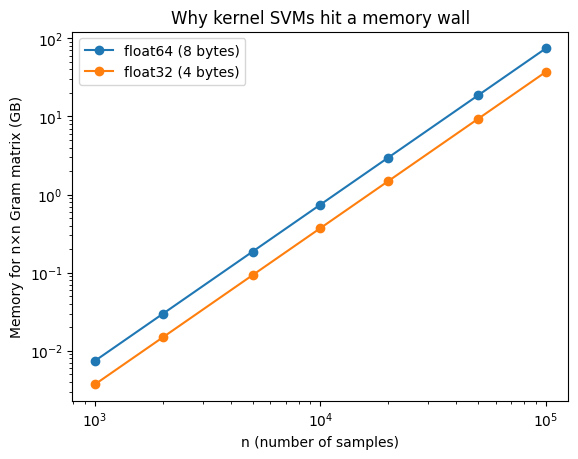

In [2]:
# Visualize the memory requirement of a full n×n Gram matrix
import numpy as np
import matplotlib.pyplot as plt

def gram_memory_gb(n, dtype_bytes=8):
    return dtype_bytes * (n**2) / (1024**3)

ns = np.array([1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000])
mem64 = [gram_memory_gb(n, 8) for n in ns]
mem32 = [gram_memory_gb(n, 4) for n in ns]

plt.figure()
plt.plot(ns, mem64, marker="o", label="float64 (8 bytes)")
plt.plot(ns, mem32, marker="o", label="float32 (4 bytes)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (number of samples)")
plt.ylabel("Memory for n×n Gram matrix (GB)")
plt.title("Why kernel SVMs hit a memory wall")
plt.legend()
plt.show()


## 2) جعبه ابزار عملی برای مقیاس‌پذیر کردن

در عمل «مقیاس‌پذیر کردن SVM» معمولاً یعنی انتخاب بین این خانواده‌ها:

### 2.1 SVM خطی (حل در پرایمال)

ایده hinge-loss + regularization را نگه می‌دارید، اما یک جداکننده **خطی** در یک فضای ویژگی (ممکن است بسیار بزرگ و تنک) آموزش می‌دهید. پیچیدگی آموزش نزدیک به:

$$
O(n\cdot d) \quad \text{در هر epoch (dense)} \qquad\text{یا}\qquad O(\text{nnz}) \quad \text{(sparse)}.
$$

### 2.2 ویژگی‌های کرنلِ تقریبی (نگاشت غیرخطی صریح)

ویژگی‌های صریح $\tilde{\phi}(x)\in\mathbb{R}^D$ می‌سازید تا:

$$
K(x,x') \approx \tilde{\phi}(x)^\top \tilde{\phi}(x').
$$

سپس یک مدل خطی روی $D$ ویژگی آموزش می‌دهید. کلید اصلی همان $D$ است (بودجه شما).

### 2.3 کاهش $n$ مؤثر

وقتی حتی مدل خطی هم سنگین باشد، از نمونه‌گیری، sketching، آموزش استریم، یا توزیع‌شده استفاده می‌کنید. این موضوع در فصل‌های بعدی آمده، اما در این درس یک الگوی کوچک `partial_fit` هم نشان می‌دهیم.

---


## 2.4 رفتار solverهای SVM کرنلی (این‌که دقیقاً «بد مقیاس می‌شود» یعنی چه)

وقتی می‌گویند «SVM کرنلی مقیاس‌پذیر نیست»، معمولاً منظورشان این است: **solver مجبور است بارها و بارها به مقادیر کرنل بین زوج‌های زیادی از نمونه‌ها دسترسی داشته باشد.**

### 2.4.1 تابع هدف در دوآل

دوآلِ SVM (حالت دودویی) چنین است:

$$
\max_{\alpha}\quad \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y_i y_j K(x_i,x_j)
$$

با قیود:

$$
0 \le \alpha_i \le C,\qquad \sum_{i=1}^n \alpha_i y_i = 0.
$$

مشاهده کلیدی: جمله درجه دوم از **همه زوج‌ها** $(i,j)$ استفاده می‌کند. حتی اگر جواب sparse باشد (بسیاری $\alpha_i=0$)، solver باید با تکرار و بررسی قیود آن sparsity را پیدا کند.

### 2.4.2 شهود SMO

بیشتر پیاده‌سازی‌های کلاسیک SVM کرنلی (از جمله libsvm) از نوعی **SMO** استفاده می‌کنند که در هر تکرار یک working set کوچک (اغلب 2 متغیر) را آپدیت می‌کند.

یک حلقه ساده‌شده SMO:

1. انتخاب یک زوج $(i,j)$ که بیشترین نقض KKT را دارد.
2. حل تحلیلی زیرمسئله 2-متغیره (وابسته به مقادیر کرنل).
3. آپدیت bias و کش کردن نتایج.
4. تکرار تا همگرایی.

چرا گران می‌شود؟ چون انتخاب working set نیاز به بررسی تعداد زیادی قید دارد و آپدیت‌ها هم به ارزیابی‌های مکرر کرنل وابسته‌اند، به‌خصوص وقتی $n$ زیاد شود.

### 2.4.3 کش کردن کرنل و هزینه پنهان محاسبات

در عمل زمان آموزش کرنلی اغلب توسط این‌ها مصرف می‌شود:

- محاسبه $K(x_i,x_j)$ برای زوج‌های زیاد
- جابه‌جایی این مقادیر در حافظه (cacheهای CPU و RAM)

حتی اگر کل Gram matrix را ذخیره نکنید، solver باز هم تعداد زیادی entry کرنل را ارزیابی می‌کند. در داده‌های بزرگ، cache-missها هزینه را بالا می‌برند.

### 2.4.4 shrinking و chunking و active set

solverهای واقعی heuristic دارند:

- **Shrinking:** حذف موقت متغیرهایی که بعید است تغییر کنند.
- **Chunking:** حل روی زیرمجموعه‌ها و سپس گسترش.
- **Active set:** تمرکز روی نقاط نزدیک حاشیه.

این‌ها کمک می‌کنند، اما ماهیت $n^2$ تعامل کرنلی را حذف نمی‌کنند؛ بیشتر «بهبود ضریب ثابت» هستند نه تغییر مرتبه رشد.

### 2.4.5 نتیجه عملی

SVM کرنلی وقتی خوب است که:

- $n$ خیلی بزرگ نباشد
- غیرخطی واقعاً لازم باشد
- و هزینه inference با تعداد support vectorها قابل قبول باشد

اگر هرکدام برقرار نبود، **به سمت خطی یا کرنلِ تقریبی بروید.**


In [3]:
# Core scientific stack
import numpy as np
import pandas as pd

# Modeling / preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# SVMs and scalable variants
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

# Kernel approximation
from sklearn.kernel_approximation import RBFSampler, Nystroem

# Synthetic data for scaling demos
from sklearn.datasets import make_classification

# Utilities
import time
import matplotlib.pyplot as plt
from pathlib import Path


## 3) بارگذاری دیتاست‌ها از مخزن (مسیرهای نسبی)

ما داده‌ها را با مسیرهای نسبی (نسبت به محل فایل نوت‌بوک در مخزن) می‌خوانیم:

- `../../../Datasets/Classification/glass.csv`
- `../../../Datasets/Classification/stars.csv`
- `../../../Datasets/Classification/diabetes.csv`

سلول بعد helper بارگذاری را تعریف می‌کند و وجود فایل را هم بررسی می‌کند.


In [4]:
def load_csv(rel_path: str) -> pd.DataFrame:
    p = Path(rel_path)
    if not p.exists():
        raise FileNotFoundError(
            f"Expected dataset at: {p.resolve()}\n"
            "Make sure you are running this notebook inside the repo and the relative paths match the repo structure."
        )
    return pd.read_csv(p)

paths = {
    "glass": "../../../Datasets/Classification/glass.csv",
    "stars": "../../../Datasets/Classification/stars.csv",
    "diabetes": "../../../Datasets/Classification/diabetes.csv",
}

glass_df = load_csv(paths["glass"])
stars_df = load_csv(paths["stars"])
diabetes_df = load_csv(paths["diabetes"])

display(glass_df.head())
display(stars_df.head())
display(diabetes_df.head())


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,Red Dwarf
1,3042,0.000500,0.1542,16.60,Red,M,Red Dwarf
2,2600,0.000300,0.1020,18.70,Red,M,Red Dwarf
3,2800,0.000200,0.1600,16.65,Red,M,Red Dwarf
4,1939,0.000138,0.1030,20.06,Red,M,Red Dwarf


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


## 4) دیتاست 1: `glass.csv` (چندکلاسه) — SVM کرنلی در برابر کرنل‌های تقریبی

### 4.1 چرا این دیتاست برای این درس مناسب است

دیتاست شیشه یک مسئله کلاسیک **چندکلاسه** با ویژگی‌های عددی (`RI, Na, Mg, ...`) و هدف `Type` است.

- آن‌قدر کوچک است که SVM کرنلی را سریع اجرا کنیم.
- آن‌قدر پیچیده است که غیرخطی کمک کند.
- برای تست **Nyström** و **RFF** بسیار مناسب است.

### 4.2 مدل‌هایی که مقایسه می‌کنیم

سه pipeline:

1. **Kernel SVM (RBF):** `SVC(kernel="rbf")`
2. **Nyström + LinearSVC:** `Nystroem` + `LinearSVC`
3. **RFF + LinearSVC:** `RBFSampler` + `LinearSVC`

همه داخل pipeline مقیاس‌دهی (`StandardScaler`) دارند تا leakage رخ ندهد.

### 4.3 درباره ابرپارامترها

- `C` معامله‌ی حاشیه و نقض قیدها را کنترل می‌کند.
- `gamma` (برای RBF) محلی بودن مرز تصمیم را کنترل می‌کند.
- `n_components` کیفیت تقریب را در Nyström/RFF کنترل می‌کند.

---


In [5]:
# Prepare X/y for the glass dataset
glass = glass_df.copy()

# Target column name in your dataset is "Type"
y_glass = glass["Type"]
X_glass = glass.drop(columns=["Type"])

X_train, X_test, y_train, y_test = train_test_split(
    X_glass, y_glass, test_size=0.25, random_state=42, stratify=y_glass
)

numeric_features = X_glass.columns.tolist()

preprocess_numeric = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop"
)

# Define three pipelines
svc_rbf = Pipeline(steps=[
    ("pre", preprocess_numeric),
    ("clf", SVC(kernel="rbf", C=10.0, gamma="scale"))
])

nystroem_linear = Pipeline(steps=[
    ("pre", preprocess_numeric),
    ("feat", Nystroem(kernel="rbf", gamma=0.2, n_components=500, random_state=42)),
    ("clf", LinearSVC(C=10.0, dual=False, max_iter=20000, random_state=42))
])

rff_linear = Pipeline(steps=[
    ("pre", preprocess_numeric),
    ("feat", RBFSampler(gamma=0.2, n_components=500, random_state=42)),
    ("clf", LinearSVC(C=10.0, dual=False, max_iter=20000, random_state=42))
])

pipelines = {
    "Kernel SVC (RBF)": svc_rbf,
    "Nyström + LinearSVC": nystroem_linear,
    "RFF (RBFSampler) + LinearSVC": rff_linear
}


In [6]:
def fit_time_score(pipe, X_train, y_train, X_test, y_test):
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    t1 = time.perf_counter()
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    return (t1 - t0), acc, f1, pred

results = []
preds = {}

for name, pipe in pipelines.items():
    dt, acc, f1m, pred = fit_time_score(pipe, X_train, y_train, X_test, y_test)
    results.append((name, dt, acc, f1m))
    preds[name] = pred

results_df = pd.DataFrame(results, columns=["Model", "Fit time (s)", "Accuracy", "Macro F1"])
results_df.sort_values("Fit time (s)", inplace=True)
results_df


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(


,Model,Fit time (s),Accuracy,Macro F1
0,Kernel SVC (RBF),0.022296,0.740741,0.703704
2,RFF (RBFSampler) + LinearSVC,0.156171,0.740741,0.651624
1,Nyström + LinearSVC,3.624714,0.740741,0.690212


### 4.4 تفسیر نتایج (دقت در برابر بودجه)

مثل یک مهندس به جدول نگاه کنید:

- اگر SVC کرنلی فقط کمی بهتر است ولی خیلی کندتر، انتخاب کرنل تقریبی منطقی است.
- اگر کرنل تقریبی خیلی دقت را کم می‌کند، `n_components` را زیاد کنید یا `gamma` را دوباره تنظیم کنید.
- اگر همه مشابه‌اند، سریع‌ترین و ساده‌ترین را بردارید.

الگوی رایج یک «زانویی» است: با افزایش `n_components` دقت اول سریع بالا می‌رود و بعد اشباع می‌شود.

در ادامه ماتریس درهم‌ریختگی سریع‌ترین مدل را رسم می‌کنیم.


Visualizing confusion matrix for: Kernel SVC (RBF)


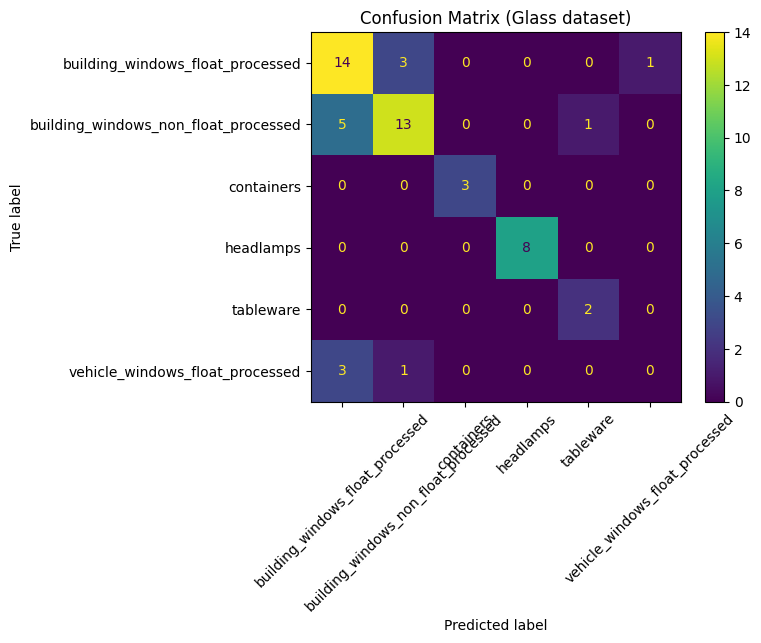

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.64      0.78      0.70        18
building_windows_non_float_processed       0.76      0.68      0.72        19
                          containers       1.00      1.00      1.00         3
                           headlamps       1.00      1.00      1.00         8
                           tableware       0.67      1.00      0.80         2
     vehicle_windows_float_processed       0.00      0.00      0.00         4

                            accuracy                           0.74        54
                           macro avg       0.68      0.74      0.70        54
                        weighted avg       0.71      0.74      0.72        54



In [7]:
# Pick a model to visualize (here: the fastest by fit time)
fastest_model = results_df.iloc[0]["Model"]
print("Visualizing confusion matrix for:", fastest_model)

best_pred = preds[fastest_model]
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, xticks_rotation=45)
plt.title("Confusion Matrix (Glass dataset)")
plt.show()

print(classification_report(y_test, best_pred))


### 4.5 جست‌وجوی `n_components` (معاوضه کیفیت تقریب و زمان)

حالا یک sweep کوچک روی `n_components` برای RFF و Nyström اجرا می‌کنیم تا ببینید:

- به ازای هر افزایش بُعد ویژگی، چقدر دقت می‌گیرید
- کجا منحنی اشباع می‌شود

> توجه: روی دیتاست‌های کوچک، نویز زمان‌سنجی زیاد است؛ برای بنچمارک جدی، چند بار تکرار کنید و میانگین±انحراف معیار بگیرید.


In [8]:
n_components_grid = [50, 100, 200, 500, 1000, 2000]

def make_rff_pipe(nc):
    return Pipeline(steps=[
        ("pre", preprocess_numeric),
        ("feat", RBFSampler(gamma=0.2, n_components=nc, random_state=42)),
        ("clf", LinearSVC(C=10.0, dual=False, max_iter=20000, random_state=42))
    ])

def make_nys_pipe(nc):
    return Pipeline(steps=[
        ("pre", preprocess_numeric),
        ("feat", Nystroem(kernel="rbf", gamma=0.2, n_components=nc, random_state=42)),
        ("clf", LinearSVC(C=10.0, dual=False, max_iter=20000, random_state=42))
    ])

rows = []
for nc in n_components_grid:
    for label, maker in [("RFF", make_rff_pipe), ("Nyström", make_nys_pipe)]:
        pipe = maker(nc)
        dt, acc, f1m, _ = fit_time_score(pipe, X_train, y_train, X_test, y_test)
        rows.append((label, nc, dt, acc, f1m))

sweep_df = pd.DataFrame(rows, columns=["Approx", "n_components", "Fit time (s)", "Accuracy", "Macro F1"])
sweep_df.sort_values(["Approx", "n_components"], inplace=True)
sweep_df


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarni

,Approx,n_components,Fit time (s),Accuracy,Macro F1
1,Nyström,50,0.470461,0.666667,0.653822
3,Nyström,100,0.733411,0.722222,0.661165
5,Nyström,200,2.036789,0.740741,0.690212
7,Nyström,500,1.886087,0.740741,0.690212
9,Nyström,1000,1.950351,0.740741,0.690212
11,Nyström,2000,0.301149,0.740741,0.690212
0,RFF,50,0.026451,0.685185,0.701337
2,RFF,100,0.040246,0.740741,0.754024
4,RFF,200,0.055745,0.703704,0.622145
6,RFF,500,0.134864,0.740741,0.651624


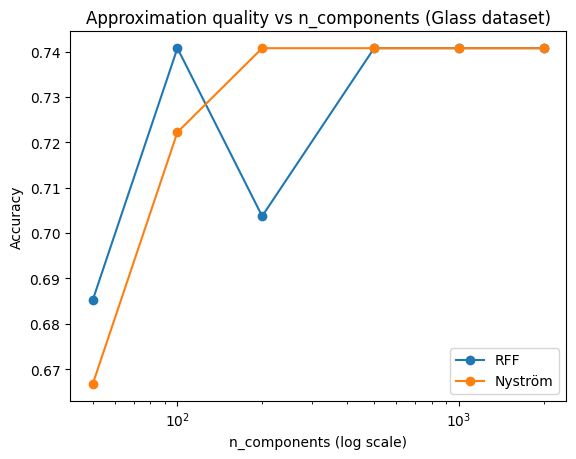

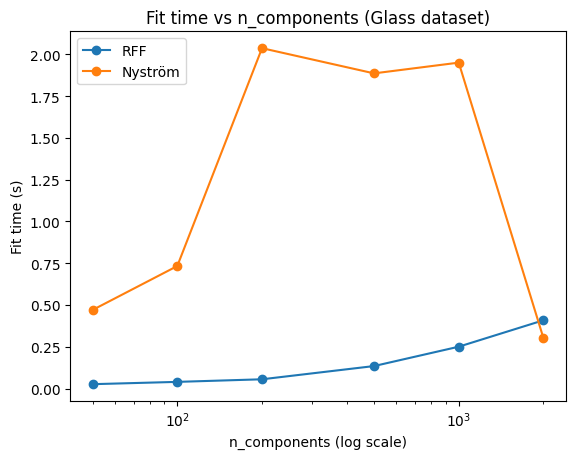

In [9]:
# Plot accuracy vs n_components
plt.figure()
for approx in ["RFF", "Nyström"]:
    sub = sweep_df[sweep_df["Approx"] == approx]
    plt.plot(sub["n_components"], sub["Accuracy"], marker="o", label=approx)
plt.xscale("log")
plt.xlabel("n_components (log scale)")
plt.ylabel("Accuracy")
plt.title("Approximation quality vs n_components (Glass dataset)")
plt.legend()
plt.show()

# Plot fit time vs n_components
plt.figure()
for approx in ["RFF", "Nyström"]:
    sub = sweep_df[sweep_df["Approx"] == approx]
    plt.plot(sub["n_components"], sub["Fit time (s)"], marker="o", label=approx)
plt.xscale("log")
plt.xlabel("n_components (log scale)")
plt.ylabel("Fit time (s)")
plt.title("Fit time vs n_components (Glass dataset)")
plt.legend()
plt.show()


### 4.6 (اختیاری) یک GridSearchCV کوچک برای کرنل‌های تقریبی

در سلول زیر یک grid search کوچک برای pipeline مبتنی بر RFF روی `glass.csv` اجرا می‌کنیم تا الگوی کار را ببینید:

- grid کوچک و منطقی
- Stratified CV
- اندازه‌گیری دقت (و در صورت نیاز زمان)

در دیتاست‌های بزرگ، معمولاً اول روی یک زیرمجموعه انجام می‌دهند.


In [10]:
# Small GridSearchCV example (RFF on glass dataset)
rff_pipe = Pipeline(steps=[
    ("pre", preprocess_numeric),
    ("feat", RBFSampler(random_state=42)),
    ("clf", LinearSVC(dual=False, max_iter=20000, random_state=42))
])

param_grid = {
    "feat__gamma": [0.05, 0.1, 0.2, 0.5],
    "feat__n_components": [200, 500, 1000],
    "clf__C": [0.5, 1.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=rff_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

t0 = time.perf_counter()
gs.fit(X_train, y_train)
t1 = time.perf_counter()

print("GridSearch fit time (s):", t1 - t0)
print("Best params:", gs.best_params_)
print("Best CV accuracy:", gs.best_score_)

best_model = gs.best_estimator_
pred = best_model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, pred))


GridSearch fit time (s): 13.618309100005717
Best params: {'clf__C': 1.0, 'feat__gamma': 0.05, 'feat__n_components': 1000}
Best CV accuracy: 0.69375
Test accuracy: 0.7222222222222222


### 4.7 Support vectorها و هزینه inference (چرا مدل‌های کرنلی در تولید می‌توانند کند باشند)

حتی اگر آموزش ممکن باشد، هزینه inference در SVM کرنلی با تعداد support vectorها رشد می‌کند.

در این سلول تعداد support vectorهای مدل کرنلی روی دیتاست شیشه را بررسی می‌کنیم و یک زمان‌سنجی ساده را با مدل خطی مقایسه می‌کنیم.


In [11]:
# Support vectors count (glass kernel SVC)
# Fit kernel model (if not already fit)
svc_rbf.fit(X_train, y_train)
svc_est = svc_rbf.named_steps["clf"]

print("Number of support vectors per class:", svc_est.n_support_)
print("Total number of support vectors:", int(np.sum(svc_est.n_support_)))

# Rough inference timing: kernel vs linear (use a small batch)
X_batch = X_test.iloc[:50]

t0 = time.perf_counter()
_ = svc_rbf.predict(X_batch)
t1 = time.perf_counter()

t2 = time.perf_counter()
_ = rff_linear.predict(X_batch)
t3 = time.perf_counter()

print("Kernel SVC predict time for 50 samples (s):", t1 - t0)
print("RFF+LinearSVC predict time for 50 samples (s):", t3 - t2)


Number of support vectors per class: [39 43  9 11  6 13]
Total number of support vectors: 121
Kernel SVC predict time for 50 samples (s): 0.005895299997064285
RFF+LinearSVC predict time for 50 samples (s): 0.005043699995439965


## 5) راهبرد 1 — SVM خطی و دلیل مقیاس‌پذیری

### 5.1 hinge در برابر squared hinge

دو loss رایج:

- hinge: $\max(0, 1 - y f(x))$
- squared hinge: $\max(0, 1 - y f(x))^2$

squared hinge نرم‌تر است و با بعضی solverها خوب کار می‌کند. در scikit-learn:

- `LinearSVC` به‌صورت پیش‌فرض **squared hinge** است.
- `SGDClassifier(loss="hinge")` hinge کلاسیک را استفاده می‌کند.

### 5.2 چرا خطی بودن اغلب کافی است

«مدل خطی» در عمل گمراه‌کننده است. جداکننده خطی در یک فضای ویژگی تبدیل‌شده می‌تواند بسیار پیچیده شود (مثلاً one-hot، bag-of-words، ویژگی‌های چندجمله‌ای یا random features).

### 5.3 شهود solver

- `LinearSVC` (liblinear): یک پیش‌فرض قوی برای دیتاست‌های متوسط.
- `SGDClassifier`: بسیار مقیاس‌پذیر، مناسب میلیون‌ها نمونه و آموزش استریم.

---


## 5.4 مکانیک بهینه‌سازی SVM خطی (زیرگرادیان، آپدیت‌های سبک Pegasos)

برای این‌که بفهمید چرا SVM خطی مقیاس‌پذیر است، یک قانون آپدیت نمونه را ببینید.

هدف regularized hinge (برای سادگی بدون bias):

$$
\min_w \quad \frac{\lambda}{2}\lVert w\rVert^2 + \frac{1}{n}\sum_{i=1}^n \max(0, 1 - y_i w^\top x_i).
$$

زیرگرادیان hinge برای یک نمونه:

- اگر $y_i w^\top x_i \ge 1$: زیرگرادیان $0$ (با حاشیه درست طبقه‌بندی شده).
- اگر $y_i w^\top x_i < 1$: زیرگرادیان $-y_i x_i$ (فشار برای افزایش margin).

پس یک گام تصادفی (یک نمونه) چنین است:

$$
w \leftarrow (1-\eta \lambda)w + \eta \, y_i x_i \, \mathbf{1}[y_i w^\top x_i < 1],
$$

که $\eta$ نرخ یادگیری است.

### Pegasos (شهود)

Pegasos یک روش کلاسیک با $\eta_t=1/(\lambda t)$ است و گاهی projection هم دارد تا $\lVert w\rVert$ کنترل شود. ویژگی مهم این است که هر تکرار **ارزان** است:

- محاسبه $w^\top x_i$ (هزینه $O(d)$ یا $O(\text{nnz})$)
- آپدیت $w$

بدون ماتریس کرنل و بدون تعامل زوجی.

### چرا «تقریباً خطی» مقیاس می‌گیرد

اگر $T$ تکرار (یا چند epoch) انجام دهید، هزینه کل:

$$
O(T\cdot d).
$$

برای بسیاری مسائل، $T$ نسبت به $n^2$ خیلی آهسته رشد می‌کند. بنابراین SVM خطی می‌تواند دیتاست‌های عظیم را مدیریت کند.

### ارتباط با `SGDClassifier`

`SGDClassifier(loss="hinge")` در همین خانواده است، با بهبودهای عملی مثل:

- schedule نرخ یادگیری
- regularization
- early stopping با `tol`

این ستون فقرات SVM خطی در مقیاس است.


## 6) دیتاست 2: `stars.csv` — SVM خطی روی داده‌های ترکیبی (عدد + دسته‌ای)

ستون‌ها شامل:

- عددی: `Temperature, L, R, A_M`
- دسته‌ای: `Color, Spectral_Class`
- هدف: `Type`

### 6.1 pipeline

یک `ColumnTransformer` می‌سازیم و سپس:

- `LinearSVC`
- `SGDClassifier(loss="hinge")`

را مقایسه می‌کنیم و یک نسخه کالیبره‌شده (اختیاری) هم نشان می‌دهیم.

---


In [12]:
stars = stars_df.copy()

# Target column is "Type"
y_stars = stars["Type"]
X_stars = stars.drop(columns=["Type"])

# Infer numeric vs categorical columns
numeric_cols = X_stars.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_stars.columns if c not in numeric_cols]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stars, y_stars, test_size=0.25, random_state=42, stratify=y_stars
)

# OneHotEncoder parameter name differs across sklearn versions; handle both.
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocess_mixed = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", ohe, categorical_cols),
    ],
    remainder="drop"
)

lin_svc = Pipeline(steps=[
    ("pre", preprocess_mixed),
    ("clf", LinearSVC(C=1.0, dual=True, max_iter=20000, random_state=42))
])

sgd_svm = Pipeline(steps=[
    ("pre", preprocess_mixed),
    ("clf", SGDClassifier(loss="hinge", alpha=1e-4, max_iter=4000, tol=1e-3, random_state=42))
])

models = {"LinearSVC": lin_svc, "SGDClassifier (hinge)": sgd_svm}

stars_results = []
stars_preds = {}

for name, pipe in models.items():
    t0 = time.perf_counter()
    pipe.fit(X_train_s, y_train_s)
    t1 = time.perf_counter()
    pred = pipe.predict(X_test_s)
    dt = t1 - t0
    acc = accuracy_score(y_test_s, pred)
    f1m = f1_score(y_test_s, pred, average="macro")
    stars_results.append((name, dt, acc, f1m))
    stars_preds[name] = pred

pd.DataFrame(stars_results, columns=["Model", "Fit time (s)", "Accuracy", "Macro F1"]).sort_values("Fit time (s)")


,Model,Fit time (s),Accuracy,Macro F1
0,LinearSVC,0.019807,1.000000,1.000000
1,SGDClassifier (hinge),0.023026,0.983333,0.983292


### 6.2 تفسیر (چرا این مقیاس‌پذیر است)

بعد از one-hot، فضای ویژگی می‌تواند بسیار بزرگ ولی تنک شود.

مدل‌های خطی با تعداد nonzeroها مقیاس می‌گیرند؛ بنابراین حتی اگر «بعد خام» بزرگ باشد، آموزش عملی می‌ماند.

در ادامه ماتریس درهم‌ریختگی مدل SVM خطی را رسم می‌کنیم.


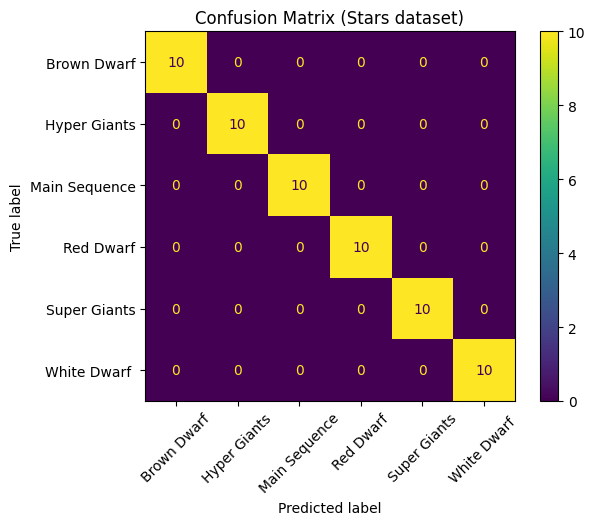

               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00        10
 Hyper Giants       1.00      1.00      1.00        10
Main Sequence       1.00      1.00      1.00        10
    Red Dwarf       1.00      1.00      1.00        10
 Super Giants       1.00      1.00      1.00        10
 White Dwarf        1.00      1.00      1.00        10

     accuracy                           1.00        60
    macro avg       1.00      1.00      1.00        60
 weighted avg       1.00      1.00      1.00        60



In [13]:
ConfusionMatrixDisplay.from_predictions(y_test_s, stars_preds["LinearSVC"], xticks_rotation=45)
plt.title("Confusion Matrix (Stars dataset)")
plt.show()

print(classification_report(y_test_s, stars_preds["LinearSVC"]))


### 6.3 اختیاری: احتمال‌ها در مقیاس (کالیبراسیون)

marginهای SVM احتمال نیستند. اگر برای آستانه‌گذاری یا تصمیم‌گیری ریسکی به احتمال کالیبره نیاز دارید:

- یک مدل margin سریع آموزش دهید (LinearSVC یا SGD).
- با `CalibratedClassifierCV` کالیبره کنید.

این معمولاً ارزان‌تر از `probability=True` در `SVC` است.

در سلول زیر یک مثال کوچک می‌بینید.


In [14]:
calibrated = Pipeline(steps=[
    ("pre", preprocess_mixed),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(C=1.0, dual=True, max_iter=20000, random_state=42),
        method="sigmoid",
        cv=3
    ))
])

t0 = time.perf_counter()
calibrated.fit(X_train_s, y_train_s)
t1 = time.perf_counter()

proba = calibrated.predict_proba(X_test_s)
pred = calibrated.predict(X_test_s)

print("Calibration fit time (s):", t1 - t0)
print("Accuracy:", accuracy_score(y_test_s, pred))
print("First 5 probability rows:")
proba[:5]


Calibration fit time (s): 0.10426550000556745
Accuracy: 0.9833333333333333
First 5 probability rows:


array([[1.46960768e-02, 2.14460715e-02, 1.30471182e-01, 4.08744530e-02,
        2.78400124e-03, 7.89728215e-01],
       [8.16052959e-01, 2.03582453e-02, 2.40475462e-02, 7.27108333e-02,
        6.18277932e-02, 5.00262320e-03],
       [5.00559958e-03, 2.20407318e-02, 3.42776251e-01, 6.37591551e-05,
        6.10120589e-01, 1.99930691e-02],
       [2.97999194e-01, 1.69246428e-02, 4.46670964e-03, 6.31986844e-01,
        1.76186337e-02, 3.10039754e-02],
       [1.30603347e-01, 1.45334049e-02, 2.14376421e-03, 7.69276898e-01,
        7.18666745e-03, 7.62559185e-02]])

## 7) راهبرد 2 — کرنل‌های تقریبی (با جزئیات بیشتر)

کرنل‌ها مرز تصمیم غیرخطی می‌دهند، اما کرنل کامل گران است. روش‌های تقریبی فضای ویژگی ضمنی را با یک نگاشت صریح محدود جایگزین می‌کنند.

دو ابزار اصلی: Random Fourier Features و Nyström.

### 7.1 RFF برای کرنل‌های shift-invariant

برای $K(x,x')=k(x-x')$:

$$
k(\delta) = \int_{\mathbb{R}^d} e^{i\omega^\top \delta} p(\omega)\, d\omega.
$$

با Monte Carlo:

$$
\tilde{\phi}(x)=\sqrt{\frac{2}{D}}[\cos(\omega_1^\top x+b_1),\dots,\cos(\omega_D^\top x+b_D)]
$$

و

$$
\tilde{\phi}(x)^\top \tilde{\phi}(x') \approx K(x,x')
$$

و خطا با $O(1/\sqrt{D})$ کم می‌شود.

### 7.2 Nyström

$$
K \approx C W^{\dagger} C^\top.
$$

### 7.3 کدام را انتخاب کنیم؟

- **RFF:** ساده، مستقل از داده، مناسب RBF.
- **Nyström:** وابسته به داده؛ وقتی ساختار low-rank داشته باشید می‌تواند بهتر شود.

---

### نقشه دوم (pipeline کرنل تقریبی)

```mermaid
flowchart TD
    A["Raw features X"] --> B["Scale/encode in Pipeline"]
    B --> C["Approx feature map (RFF or Nyström)"]
    C --> D["Linear model (LinearSVC / SGD)"]
    D --> E["Validation + tuning"]
    E --> F["(Optional) calibration"]
```

---


## 7.4 استخراج Random Fourier Features برای کرنل RBF (ریاضی بیشتر)

این بخش استخراج واضح‌تری برای حالت RBF می‌دهد. لازم نیست حفظ کنید، اما فهم ساختار کمک می‌کند هنگام تنظیم `gamma` و `n_components` شهود داشته باشید.

### 7.4.1 شروع از کرنل shift-invariant

اگر $K(x,x')=k(x-x')$ باشد، کرنل shift-invariant است. RBF:

$$
K(x,x') = \exp(-\gamma \lVert x-x'\rVert^2).
$$

اگر $\delta=x-x'$، آنگاه $k(\delta)=\exp(-\gamma \lVert \delta\rVert^2)$.

### 7.4.2 تبدیل فوریه گاوسی

یک حقیقت مهم: تبدیل فوریه یک گاوسی خودش گاوسی است. در $d$ بعد (تا یک ثابت):

$$
\int_{\mathbb{R}^d} \exp(-\gamma \lVert \delta\rVert^2) \, e^{-i\omega^\top \delta} \, d\delta
\propto \exp\left(-\frac{\lVert\omega\rVert^2}{4\gamma}\right).
$$

پس چگالی طیفی $p(\omega)$ برای RBF یک گاوسی است:

$$
\omega \sim \mathcal{N}(0, 2\gamma I).
$$

(ثابت‌ها به قرارداد تبدیل فوریه وابسته‌اند؛ شکل گاوسی و وابستگی به $\gamma$ مهم است.)

### 7.4.3 تبدیل امیدریاضی به ویژگی صریح

با ترفند فاز تصادفی می‌توان نوشت:

$$
K(x,x') = \mathbb{E}_{\omega,b}\left[\sqrt{2}\cos(\omega^\top x + b)\;\sqrt{2}\cos(\omega^\top x' + b)\right],
$$

که $b\sim \text{Unif}[0,2\pi]$ و $\omega\sim p(\omega)$.

با میانگین‌گیری روی $D$ نمونه:

$$
\tilde{\phi}(x)=\sqrt{\frac{2}{D}}\,[\cos(\omega_1^\top x + b_1),\dots,\cos(\omega_D^\top x + b_D)].
$$

و:

$$
\tilde{\phi}(x)^\top \tilde{\phi}(x') \approx K(x,x').
$$

### 7.4.4 چرا scaling مهم است

ویژگی‌ها تابع $\omega^\top x$ هستند. اگر یک ویژگی دامنه خیلی بزرگ‌تری داشته باشد، ضرب داخلی را غالب می‌کند و عملاً طول‌مقیاس کرنل را خراب می‌کند. بنابراین قبل از RFF/Nyström مقیاس‌دهی ضروری است.

### 7.4.5 تفسیر `gamma` به عنوان length-scale

گاهی RBF را این‌طور می‌نویسند:

$$
K(x,x') = \exp\left(-\frac{\lVert x-x'\rVert^2}{2\sigma^2}\right).
$$

که با $\exp(-\gamma\lVert x-x'\rVert^2)$ مقایسه کنیم:

$$
\gamma = \frac{1}{2\sigma^2}.
$$

پس $\gamma$ بزرگ یعنی $\sigma$ کوچک → کرنل خیلی محلی → احتمال overfitting اگر خیلی محلی شود.

---


## 7.5 خطای تقریب و انتخاب `n_components` (فکر کردن در قالب «واریانس»)

RFF و بسیاری از تقریب‌های تصادفی مثل یک estimator مونت‌کارلو رفتار می‌کنند: امیدریاضی را با میانگین محدود تقریب می‌زنید.

### 7.5.1 داستان ساده واریانس

فرض کنید یک متغیر تصادفی $Z$ داریم که امیدریاضی‌اش برابر مقدار کرنل است:

$$
K(x,x') = \mathbb{E}[Z].
$$

با $D$ نمونه مستقل:

$$
\hat{K}_D(x,x') = \frac{1}{D}\sum_{j=1}^D Z_j.
$$

آنگاه:

$$
\mathrm{Var}(\hat{K}_D) = \frac{1}{D}\mathrm{Var}(Z).
$$

پس انحراف معیار مثل $1/\sqrt{D}$ کم می‌شود. این مستقیماً تضمین دقت طبقه‌بندی نیست، اما توضیح می‌دهد چرا منحنی «زانویی» می‌بینید: افزایش‌های اولیه $D$ نویز تقریب را سریع کم می‌کند، افزایش‌های بعدی سود کمی دارند.

### 7.5.2 معاوضه bias/variance در Nyström

Nyström بیشتر شبیه تقریب low-rank است:

- اگر ماتریس کرنل واقعاً نزدیک رتبه $m$ باشد، Nyström با $m$ کوچک هم دقیق می‌شود
- اگر نباشد، به $m$ بزرگ‌تر نیاز دارد

انتخاب landmark مهم است. انتخاب تصادفی ساده است؛ روش‌های هوشمندتر (مرکزهای k-means، leverage score) کیفیت را بهتر می‌کنند ولی هزینه دارند.

### 7.5.3 heuristicهای عملی

1. **بودجه تعیین کنید:** یک سقف برای `n_components` که می‌توانید بپردازید.
2. **`gamma` را حدودی تنظیم کنید:** یک grid کوچک؛ `gamma="scale"` هم baseline است.
3. **`n_components` را تا اشباع افزایش دهید:** نمودار دقت در برابر `n_components`.
4. **اگر ناپایدار است:** `n_components` را افزایش دهید یا روی چند seed میانگین بگیرید.

### 7.5.4 اگر D خیلی بزرگ شود چه؟

وقتی $D$ بسیار بزرگ می‌شود (مثلاً 50k یا 100k)، به سمت نمایش بسیار بزرگ ویژگی می‌روید و آن‌جا:

- حافظه $n\times D$ غالب می‌شود
- solverهای خطی کندتر می‌شوند
- بسته به مسئله، شاید مدل‌های غیرخطی دیگر (مثل tree/GBDT) مناسب‌تر باشند

پس `n_components` یک knob است، نه یک ناهار رایگان.


## 8) دیتاست 3: `diabetes.csv` — رفتار مقیاس با افزایش اندازه نمونه

ما:

1. یک SVM کرنلی (RBF) و یک جایگزین مقیاس‌پذیر (RFF + LinearSVC) آموزش می‌دهیم.
2. با bootstrapping اندازه مؤثر training را زیاد می‌کنیم و زمان fit را می‌سنجیم.
3. یک مدل خطی استریم با `SGDClassifier.partial_fit` هم مقایسه می‌کنیم.

---


In [15]:
diab = diabetes_df.copy()

y_diab = diab["classification"]
X_diab = diab.drop(columns=["classification"])

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diab, y_diab, test_size=0.25, random_state=42, stratify=y_diab
)

num_cols_d = X_diab.columns.tolist()

preprocess_d = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols_d)],
    remainder="drop"
)

svc_rbf_d = Pipeline(steps=[
    ("pre", preprocess_d),
    ("clf", SVC(kernel="rbf", C=5.0, gamma="scale"))
])

rff_lin_d = Pipeline(steps=[
    ("pre", preprocess_d),
    ("feat", RBFSampler(gamma=0.5, n_components=800, random_state=42)),
    ("clf", LinearSVC(C=5.0, dual=False, max_iter=30000, random_state=42))
])

# Baseline evaluation on the original split
base_rows = []
for name, pipe in {"Kernel SVC (RBF)": svc_rbf_d, "RFF + LinearSVC": rff_lin_d}.items():
    t0 = time.perf_counter()
    pipe.fit(X_train_d, y_train_d)
    t1 = time.perf_counter()
    pred = pipe.predict(X_test_d)
    base_rows.append((name, t1 - t0, accuracy_score(y_test_d, pred), f1_score(y_test_d, pred, average="macro")))

pd.DataFrame(base_rows, columns=["Model", "Fit time (s)", "Accuracy", "Macro F1"])


,Model,Fit time (s),Accuracy,Macro F1
0,Kernel SVC (RBF),0.033455,0.755208,0.727725
1,RFF + LinearSVC,0.176060,0.703125,0.659097


In [16]:
# Timing experiment: grow training set size by resampling with replacement
rng = np.random.default_rng(42)

def bootstrap_rows(X, y, n_rows):
    idx = rng.integers(0, len(X), size=n_rows)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

sizes = [len(X_train_d), 2*len(X_train_d), 4*len(X_train_d), 8*len(X_train_d)]
timings = {"Kernel SVC (RBF)": [], "RFF + LinearSVC": []}

for n_rows in sizes:
    Xb, yb = bootstrap_rows(X_train_d, y_train_d, n_rows)
    
    # Kernel SVC
    t0 = time.perf_counter()
    svc_rbf_d.fit(Xb, yb)
    t1 = time.perf_counter()
    timings["Kernel SVC (RBF)"].append(t1 - t0)
    
    # RFF + LinearSVC
    t0 = time.perf_counter()
    rff_lin_d.fit(Xb, yb)
    t1 = time.perf_counter()
    timings["RFF + LinearSVC"].append(t1 - t0)

timings_df = pd.DataFrame({
    "n_train": sizes,
    "Kernel SVC (RBF) time (s)": timings["Kernel SVC (RBF)"],
    "RFF + LinearSVC time (s)": timings["RFF + LinearSVC"],
})
timings_df


,n_train,Kernel SVC (RBF) time (s),RFF + LinearSVC time (s)
0,576,0.031063,0.185210
1,1152,0.087519,0.505164
2,2304,0.265470,1.004736
3,4608,0.966828,3.920848


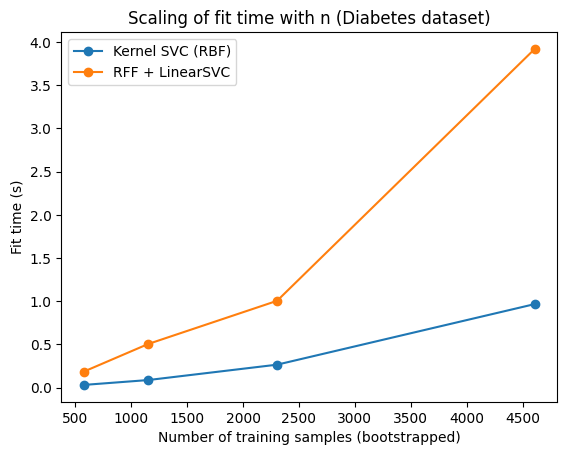

In [17]:
plt.figure()
plt.plot(timings_df["n_train"], timings_df["Kernel SVC (RBF) time (s)"], marker="o", label="Kernel SVC (RBF)")
plt.plot(timings_df["n_train"], timings_df["RFF + LinearSVC time (s)"], marker="o", label="RFF + LinearSVC")
plt.xlabel("Number of training samples (bootstrapped)")
plt.ylabel("Fit time (s)")
plt.title("Scaling of fit time with n (Diabetes dataset)")
plt.legend()
plt.show()


### 8.1 آموزش استریم با `partial_fit` (SVM خطی با SGD)

وقتی داده به صورت batch می‌آید یا کل داده در RAM جا نمی‌شود، می‌توانید یک SVM خطی با SGD را به‌صورت افزایشی آموزش دهید.

الگوی حداقلی:

1. پیش‌پردازش (مثل scaler) را روی یک batch اولیه fit کنید (یا از آمارهای درحال‌اجرا استفاده کنید).
2. روی mini-batchها `partial_fit` را چند بار صدا بزنید.

در اینجا برای سادگی scaler را روی کل train fit می‌کنیم و سپس آموزش را batchی انجام می‌دهیم (هدف آموزشی است).


In [18]:
from sklearn.preprocessing import StandardScaler

# Prepare scaled numeric arrays for streaming
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_d.values)
X_test_scaled = scaler.transform(X_test_d.values)

# SGDClassifier supports partial_fit
classes = np.unique(y_train_d)

sgd_stream = SGDClassifier(loss="hinge", alpha=1e-4, random_state=42)

batch_size = 64
n_epochs = 10

t0 = time.perf_counter()
for epoch in range(n_epochs):
    # shuffle indices
    idx = rng.permutation(len(X_train_scaled))
    for start in range(0, len(idx), batch_size):
        batch_idx = idx[start:start+batch_size]
        Xb = X_train_scaled[batch_idx]
        yb = y_train_d.iloc[batch_idx].values
        if epoch == 0 and start == 0:
            sgd_stream.partial_fit(Xb, yb, classes=classes)
        else:
            sgd_stream.partial_fit(Xb, yb)
t1 = time.perf_counter()

pred = sgd_stream.predict(X_test_scaled)
print("Streaming SGD fit time (s):", t1 - t0)
print("Accuracy:", accuracy_score(y_test_d, pred))


Streaming SGD fit time (s): 0.15941010000096867
Accuracy: 0.7239583333333334


### 8.2 چه چیزی باید ببینید

- SVC کرنلی معمولاً با $n$ **فراخطی** رشد می‌کند.
- RFF + LinearSVC برای `n_components` ثابت نزدیک‌تر به **خطی** رشد می‌کند.
- SGD استریم می‌تواند بسیار سریع و کم‌حافظه باشد و وقتی $n$ واقعاً بزرگ است انتخاب پیش‌فرض می‌شود.

معاوضه در تنظیم است: مدل‌های SGD ممکن است به دقت بیشتری در انتخاب regularization و epochها نیاز داشته باشند.

---


## 9) یک دموی مصنوعی مقیاس (جداپذیری خطی در بُعد بالا)

گاهی دیتاست‌های واقعی آن‌قدر بزرگ نیستند که تفاوت مقیاس به‌وضوح دیده شود. برای ساخت شهود، یک مسئله طبقه‌بندی مصنوعی با اندازه و بُعد کنترل‌شده می‌سازیم.

مقایسه می‌کنیم:

- `SVC(kernel="rbf")` در اندازه‌های متوسط (برای جلوگیری از زمان خیلی زیاد)
- `LinearSVC`
- `SGDClassifier(loss="hinge")`

هدف بهترین دقت نیست؛ هدف دیدن **رفتار زمان اجرا با تغییر n و d** است.


In [19]:
def benchmark_models(n_samples, n_features, random_state=42):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=max(2, n_features//10),
        n_redundant=0,
        n_classes=2,
        random_state=random_state
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state, stratify=y
    )
    
    models = {
        "Kernel SVC (RBF)": Pipeline([("sc", StandardScaler()), ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))]),
        "LinearSVC": Pipeline([("sc", StandardScaler()), ("clf", LinearSVC(C=1.0, dual=False, max_iter=20000, random_state=random_state))]),
        "SGD (hinge)": Pipeline([("sc", StandardScaler()), ("clf", SGDClassifier(loss="hinge", alpha=1e-4, max_iter=2000, tol=1e-3, random_state=random_state))])
    }
    
    rows = []
    for name, m in models.items():
        t0 = time.perf_counter()
        m.fit(X_train, y_train)
        t1 = time.perf_counter()
        pred = m.predict(X_test)
        rows.append((name, t1-t0, accuracy_score(y_test, pred)))
    return pd.DataFrame(rows, columns=["Model", "Fit time (s)", "Accuracy"])

benchmarks = []
for n in [1000, 2000, 5000]:
    dfb = benchmark_models(n_samples=n, n_features=200)
    dfb["n_samples"] = n
    dfb["n_features"] = 200
    benchmarks.append(dfb)

bench_df = pd.concat(benchmarks, ignore_index=True)
bench_df


,Model,Fit time (s),Accuracy,n_samples,n_features
0,Kernel SVC (RBF),0.117107,0.8120,1000,200
1,LinearSVC,0.042828,0.8040,1000,200
2,SGD (hinge),0.066819,0.8000,1000,200
3,Kernel SVC (RBF),0.465549,0.7780,2000,200
4,LinearSVC,0.070475,0.7820,2000,200
5,SGD (hinge),0.127340,0.7540,2000,200
6,Kernel SVC (RBF),3.370252,0.8360,5000,200
7,LinearSVC,0.128394,0.7960,5000,200
8,SGD (hinge),0.373805,0.7472,5000,200


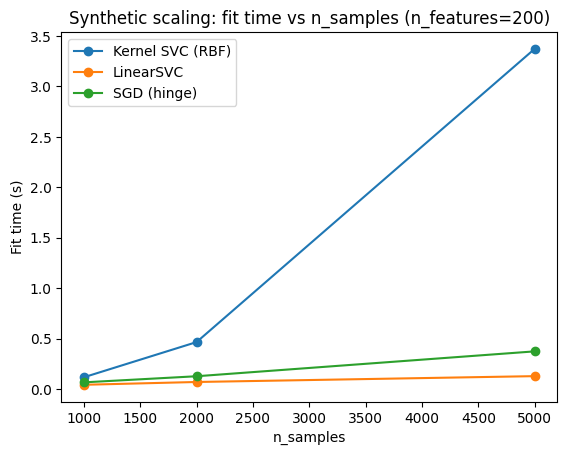

In [20]:
# Plot fit time vs n_samples for each model
plt.figure()
for model in bench_df["Model"].unique():
    sub = bench_df[bench_df["Model"] == model].sort_values("n_samples")
    plt.plot(sub["n_samples"], sub["Fit time (s)"], marker="o", label=model)
plt.xlabel("n_samples")
plt.ylabel("Fit time (s)")
plt.title("Synthetic scaling: fit time vs n_samples (n_features=200)")
plt.legend()
plt.show()


## 10) تاکتیک‌های مهندسی برای جریان‌های کاری SVM (چک‌لیست + دام‌ها)

### 10.1 همه چیز داخل Pipeline

Pipeline باعث می‌شود scaling/encoding داخل foldها انجام شود و leakage رخ ندهد، و همچنین کل فرآیند deployable باشد.

### 10.2 انتخاب solver خطی

- داده در حافظه جا می‌شود و یک پیش‌فرض قوی می‌خواهید: `LinearSVC`
- داده بسیار بزرگ/استریم: `SGDClassifier(loss="hinge")`
- غیرخطی لازم است ولی کرنل کامل گران: `RBFSampler` یا `Nystroem` + مدل خطی

### 10.3 سروینگ مهم است

SVM کرنلی با تعداد support vectorها مقیاس می‌گیرد، مدل خطی سریع و قابل پیش‌بینی است.

### 10.4 کالیبراسیون یک مرحله جداست

Margin احتمال نیست. اگر احتمال لازم دارید، کالیبره کنید یا هزینه `probability=True` را بپذیرید.

### 10.5 خطاهای رایج در مقیاس

1. مقیاس ندادن ویژگی‌ها
2. leakage با scaling روی کل داده قبل از split
3. بزرگ کردن بی‌دلیل `n_components`
4. نتیجه‌گیری از یک بار زمان‌سنجی (نویز زیاد)
5. معیار نامناسب در داده نامتوازن

---


## 11) یک لنز نظری: چرا تقریب اغلب کار می‌کند (جزئیات بیشتر)

این بخش اختیاری است اما یک مدل ذهنی بهتر می‌دهد.

### 11.1 اصل حاشیه بزرگ و کنترل ظرفیت

SVM بین دو نیرو تعادل می‌گذارد:

1. کمینه کردن hinge loss روی داده آموزش
2. کمینه کردن نورم مدل (کنترل ظرفیت)

در فضای خطی: $\lVert w\rVert^2$
در RKHS: $\lVert f\rVert_{\mathcal{H}}^2$

اگر هندسه فضای ویژگی تقریباً حفظ شود، رفتار تعمیم هم معمولاً نزدیک می‌ماند.

### 11.2 RFF به عنوان Monte Carlo

برای کرنل‌های shift-invariant، کرنل یک امیدریاضی است و با جایگزینی آن با متوسط نمونه‌ای از $D$ نمونه، واریانس مثل $1/D$ کم می‌شود. همین باعث نرخ $O(1/\sqrt{D})$ می‌شود.

### 11.3 پایداری در برابر اغتشاش کرنل (طرح کلی)

اگر:

$$
|K(x,x') - \tilde{K}(x,x')| \le \varepsilon,
$$

با regularization معمولاً پاسخ نسبت به اغتشاش کوچک پایدار است، تا وقتی که نویز آماری غالب نشود. همین با تجربه‌ی «اشباع» در `n_components` سازگار است.

---


## 11.4 یک «کاربرگ بودجه‌بندی پیچیدگی» (چطور سیستماتیک تصمیم بگیریم)

در سیستم‌های واقعی، سؤال معمولاً این نیست که «بهترین مدل» چیست. سؤال این است:

> **بهترین مدلی که در بودجه latency + حافظه + زمان آموزش جا شود کدام است؟**

یک کاربرگ ساده:

### گام 1: قیود را تعریف کنید

- بودجه آموزش: مثلاً 10 دقیقه روی یک CPU
- بودجه حافظه: مثلاً 2GB برای ویژگی‌ها در آموزش
- بودجه inference: مثلاً 5ms برای هر درخواست
- هدف دقت: مثلاً macro F1 ≥ 0.80

### گام 2: خانواده مدل را به هزینه نگاشت کنید

| خانواده مدل | حافظه آموزش | رشد زمان آموزش | زمان inference |
|---|---:|---:|---:|
| Kernel SVC (RBF) | $O(n^2)$ | شدید (اغلب فراخطی) | $O(|SV|\cdot d)$ |
| LinearSVC | $O(nd)$ یا nnz | نزدیک خطی در هر epoch | $O(d)$ |
| SGD (hinge) | $O(d)$ تا $O(nnz)$ | نزدیک خطی، استریم | $O(d)$ |
| RFF/Nyström + linear | $O(nD)$ | نزدیک خطی در $nD$ | $O(D)$ |

### گام 3: ساده‌ترین خانواده‌ای که هدف را می‌زند انتخاب کنید

1. از baseline خطی شروع کنید.
2. اگر دقت کم بود، غیرخطی را با ویژگی‌های تقریبی اضافه کنید.
3. فقط اگر $n$ کوچک است و inference قابل قبول است سراغ کرنل کامل بروید.

### گام 4: تنظیم داخل خانواده

- خطی: تنظیم `C` (یا `alpha` برای SGD) و epoch و class weights
- RFF/Nyström: تنظیم `gamma` و `n_components` و سپس `C`

این کاربرگ یک رویه تصمیم‌گیری عملی است.


## 12) تمرین‌ها (پیشنهاد می‌شود)

1. **تنظیم `n_components`:** روی `glass.csv` grid برای `n_components ∈ {50, 100, 200, 500, 1000, 2000}` اجرا کنید و دقت/زمان را برای RFF و Nyström رسم کنید.
2. **تنظیم `gamma`:** `gamma ∈ {0.05, 0.1, 0.2, 0.5, 1.0}` را بررسی کنید.
3. **squared hinge در برابر hinge:** روی `diabetes.csv`، `LinearSVC(loss="squared_hinge")` را با `SGDClassifier(loss="hinge")` مقایسه کنید.
4. **اثر کالیبراسیون:** یک مدل خطی روی `stars.csv` کالیبره کنید و هیستوگرام احتمال‌ها را بررسی کنید (اختیاری).
5. **تحلیل سروینگ:** تعداد support vectorها را از مدل کرنلی بگیرید (`svc.support_.shape[0]`) و هزینه inference را نسبت به مدل خطی تخمین بزنید.

---


## پرسش‌های رایج در مقیاس‌پذیر کردن SVM

### Q1) `SVC(kernel="linear")` یا `LinearSVC`؟

اگر مدل خطی می‌خواهید، معمولاً `LinearSVC` (liblinear) یا برای مقیاس خیلی بزرگ `SGDClassifier` بهتر است. `SVC(kernel="linear")` هنوز از machinery libsvm استفاده می‌کند و می‌تواند برای داده بزرگ کندتر/حافظه‌برتر باشد.

### Q2) رابطه `C` و `alpha` چیست؟

- `C` وزن جریمه در فرمول‌بندی کلاسیک SVM است.
- `alpha` در APIهای سبک SGD معمولاً ضریب regularization $\ell_2$ است.

به‌صورت کلی، `C` بزرگ‌تر یعنی regularization کمتر، و `alpha` بزرگ‌تر یعنی regularization بیشتر. نگاشت دقیق به قرارداد loss و مقیاس‌دهی با $n$ وابسته است، پس آن را به عنوان «شدت منظم‌سازی معکوس» در نظر بگیرید.

### Q3) RBF خوب کار نمی‌کند؛ مشکل چیست؟

علت‌های رایج:

- مقیاس‌دهی نکردن ویژگی‌ها
- `gamma` خیلی بزرگ (خیلی محلی) یا خیلی کوچک (خیلی صاف)
- نامتوازن بودن کلاس‌ها (از `class_weight="balanced"` و معیار مناسب استفاده کنید)

### Q4) چه زمانی کرنل تقریبی کمک نمی‌کند؟

- مسئله اساساً خطی است (تقریب فقط نویز/هزینه اضافه می‌کند)
- غیرخطی خیلی پیچیده لازم دارید و $D$ موردنیاز از بودجه شما خارج است
- scaling ناپایدار است یا distribution shift شدید دارید

### Q5) «مقیاس‌پذیرترین» انتخاب SVM چیست؟

برای دیتاست‌های واقعاً عظیم، پاسخ استاندارد:

- مدل margin خطی با SGD (hinge loss) روی ویژگی‌های مهندسی‌شده

این هسته بسیاری از طبقه‌بندهای صنعتی، خصوصاً در داده‌های تنک، است.


## منابع و مطالعه بیشتر

- C. Cortes and V. Vapnik, “Support-Vector Networks,” *Machine Learning*, 1995.
- N. Cristianini and J. Shawe-Taylor, *An Introduction to Support Vector Machines*, Cambridge University Press, 2000.
- B. Schölkopf and A. Smola, *Learning with Kernels*, MIT Press, 2002.
- A. Rahimi and B. Recht, “Random Features for Large-Scale Kernel Machines,” NeurIPS 2007.
- P. Drineas and M. Mahoney, “On the Nyström Method for Approximating a Gram Matrix for Improved Kernel-Based Learning,” JMLR 2005.
- مستندات scikit-learn: `SVC`, `LinearSVC`, `SGDClassifier`, `RBFSampler`, `Nystroem`, `CalibratedClassifierCV`.

---

### جمع‌بندی (یک پاراگراف)

SVMهای کرنلی قدرتمندند اما با دیوار حافظه $O(n^2)$ و رشد شدید زمان مواجه می‌شوند. مقیاس‌پذیر کردن SVM در عمل یعنی رفتن به سمت **SVM خطی در پرایمال** یا استفاده از **نگاشت‌های ویژگی کرنلِ تقریبی** (RFF/Nyström) تا بتوانید یک مدل خطی آموزش دهید. مهارت اصلی بودجه‌بندی است: مقدار غیرخطی بودنِ قابل‌پرداخت را تعیین کنید، دقت/زمان را اندازه بگیرید و ساده‌ترین مدلی را انتخاب کنید که نیاز را برآورده کند.
